<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Photobiomodulation_Effects_on_Hemodynamic_Pressure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 452ms


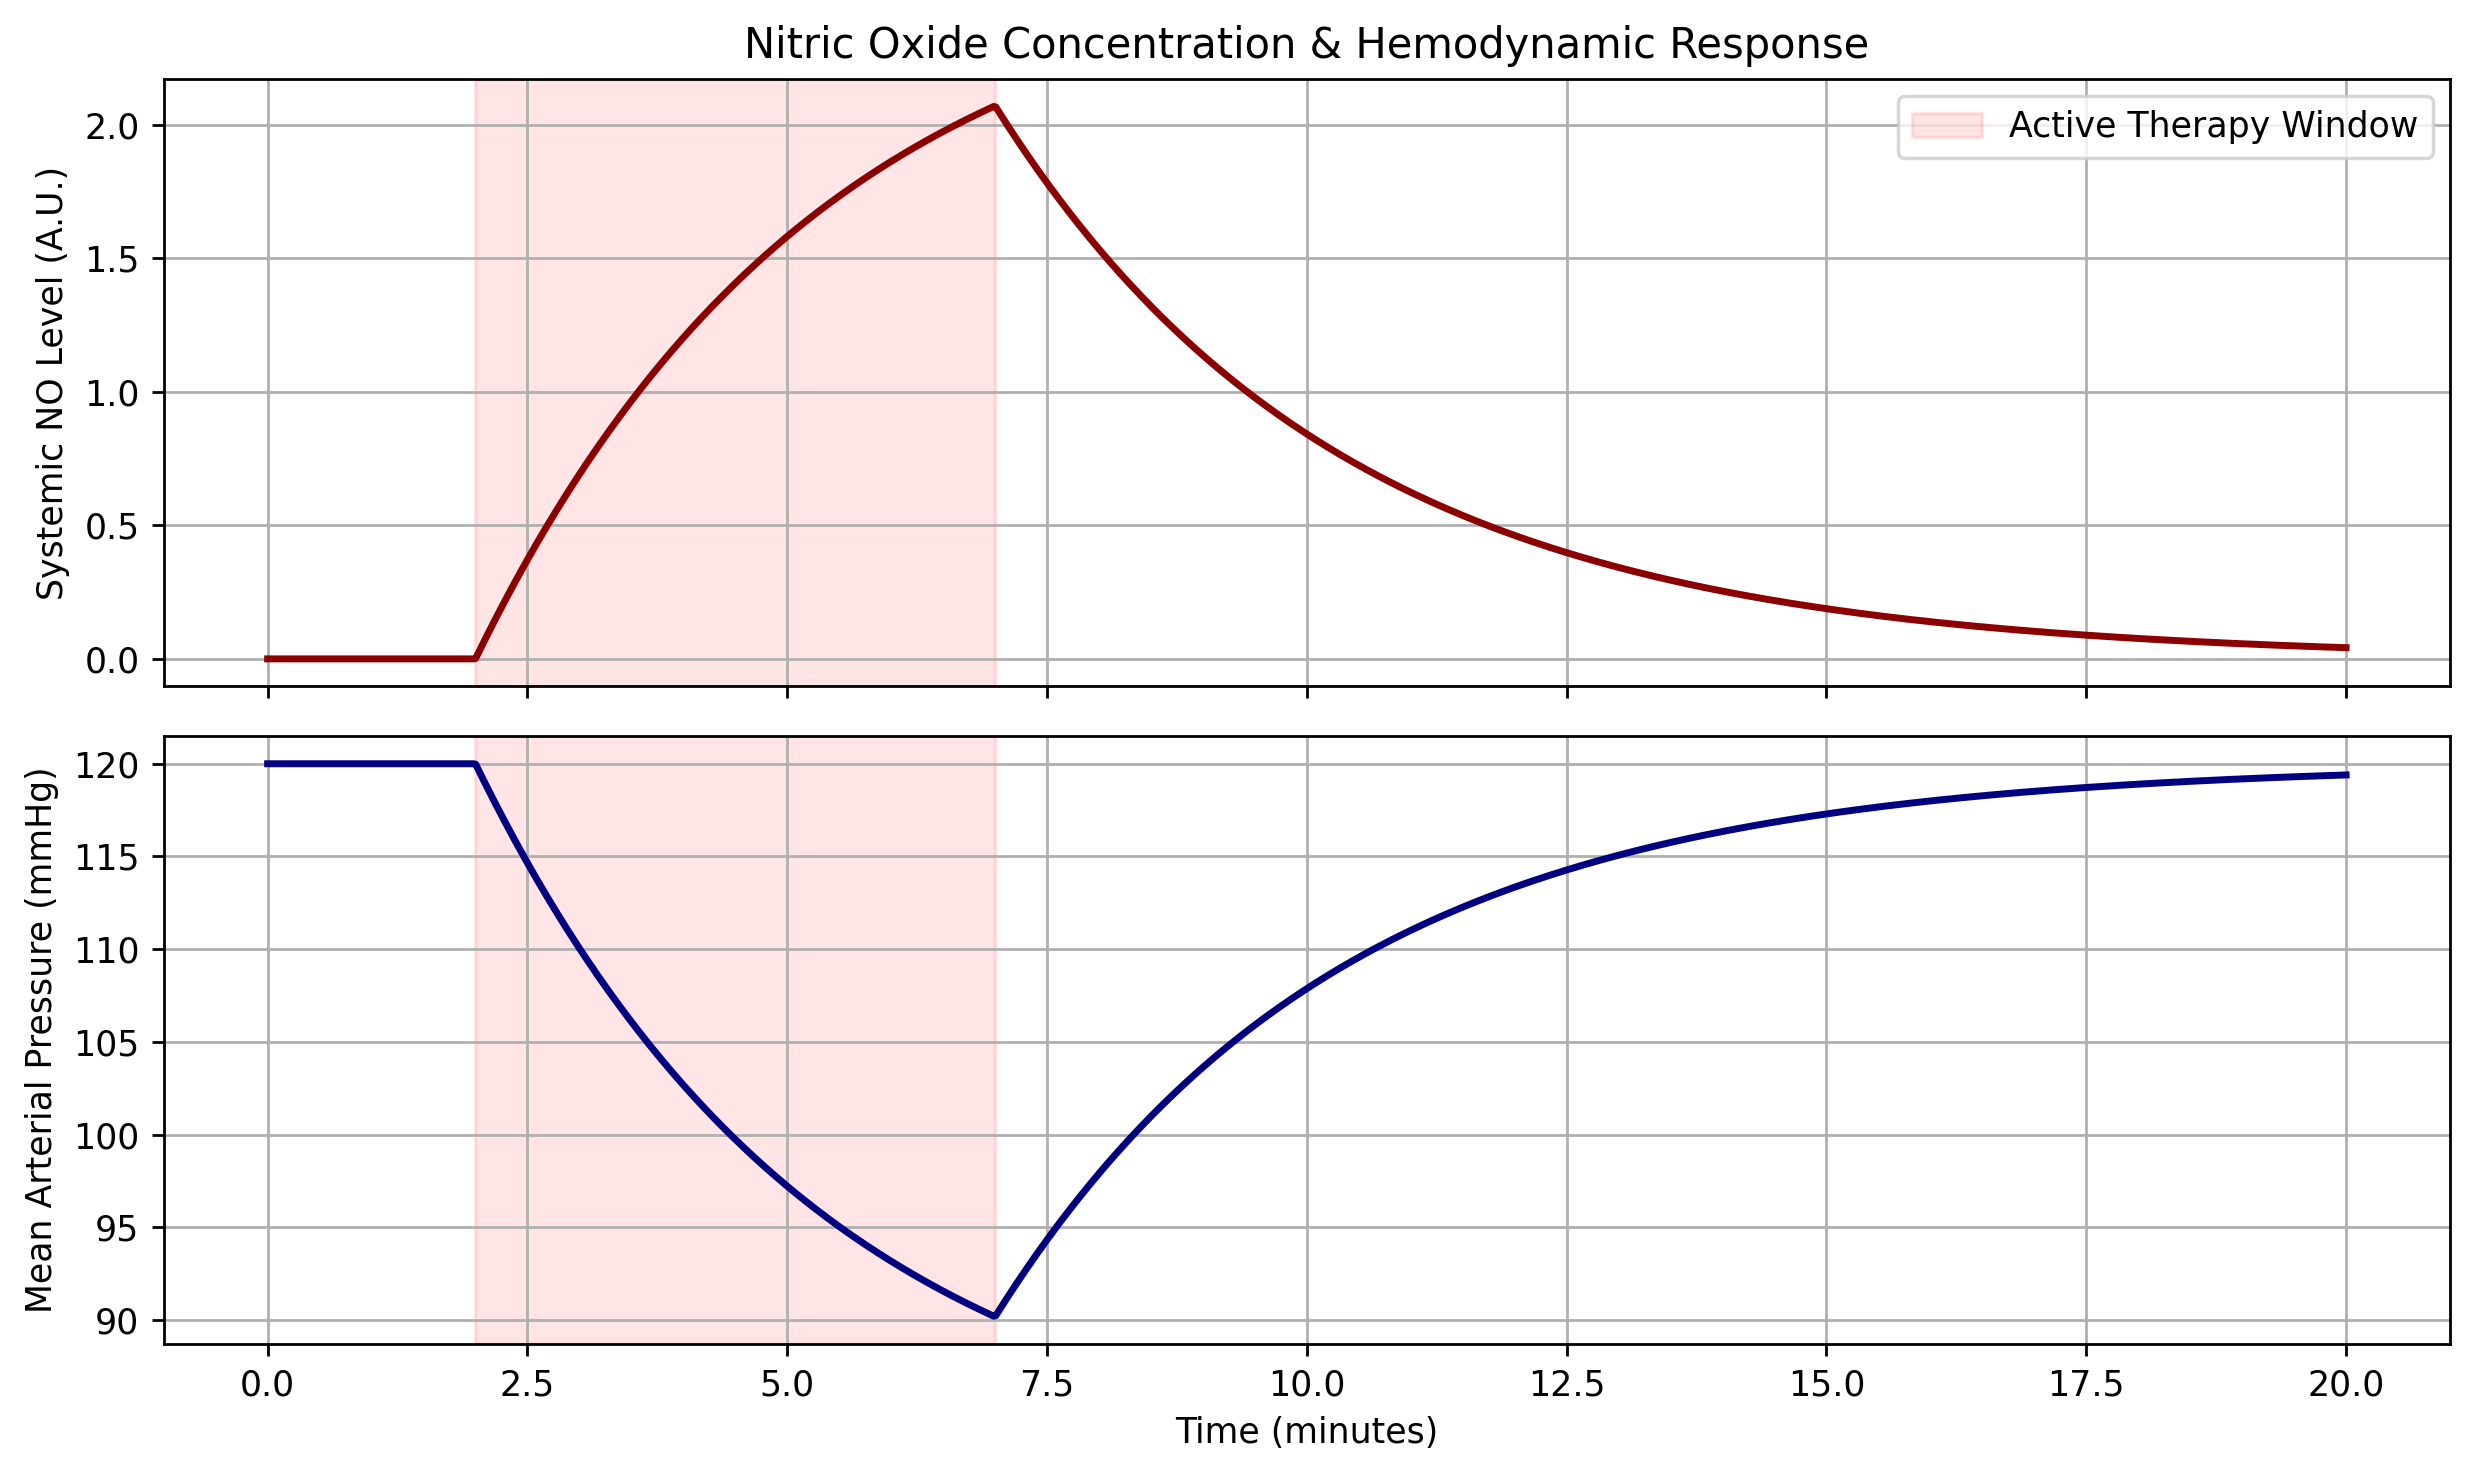

In [ ]:
!uv pip install numpy scipy matplotlib

"""
Simulates the hemodynamic pressure response to brief photobiomodulation therapy.
This script employs a numerical differential equation solver to model
nitric oxide kinetics and subsequent vasodilation.
"""

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Colab rendering parameters
plt.rcParams['figure.dpi'] = 250
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# =============================================================================
# CONTROL KNOBS (Adjustable Physiological & Simulation Parameters)
# =============================================================================
PBM_START_TIME = 2.0             # Time (minutes) when light therapy begins
PBM_DURATION = 5.0               # Duration (minutes) of light therapy
SIMULATION_END_TIME = 20.0       # Total duration (minutes) of the simulation
TIME_STEPS = 1000                # Resolution of the numerical simulation

BASELINE_MAP = 120.0             # Initial Mean Arterial Pressure (mmHg)
BASELINE_TPR = 1.0               # Normalized Total Peripheral Resistance
CARDIAC_OUTPUT = BASELINE_MAP / BASELINE_TPR # Assuming constant CO throughout

NO_PRODUCTION_RATE = 0.8         # k_prod: Rate of NO release during irradiance
NO_DECAY_RATE = 0.3              # k_decay: Biological half-life decay factor
VASODILATION_SENSITIVITY = 0.12  # alpha: Sensitivity of TPR to NO concentration
# =============================================================================

def irradiance_function(t):
    """
    Determines the active state of the light therapy device at a given time.
    Returns 1.0 if the therapy is active, and 0.0 otherwise.
    """
    if PBM_START_TIME <= t <= (PBM_START_TIME + PBM_DURATION):
        return 1.0
    return 0.0

def nitric_oxide_kinetics(no_concentration, t):
    """
    Calculates the derivative of nitric oxide concentration over time.
    """
    production = NO_PRODUCTION_RATE * irradiance_function(t)
    decay = NO_DECAY_RATE * no_concentration
    return production - decay

def run_simulation():
    """
    Executes the numerical integration and visualizes the physiological response.
    """
    time_array = np.linspace(0, SIMULATION_END_TIME, TIME_STEPS)
    initial_no_concentration = 0.0

    # Solve the ordinary differential equation for NO concentration
    no_solution = odeint(
        nitric_oxide_kinetics,
        initial_no_concentration,
        time_array
    ).flatten()

    # Calculate the corresponding physiological changes
    tpr_array = BASELINE_TPR * (1.0 - VASODILATION_SENSITIVITY * no_solution)
    map_array = CARDIAC_OUTPUT * tpr_array

    # Construct the continuous visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    ax1.plot(time_array, no_solution, color='darkred', linewidth=2.0)
    ax1.axvspan(
        PBM_START_TIME,
        PBM_START_TIME + PBM_DURATION,
        color='red',
        alpha=0.1,
        label='Active Therapy Window'
    )
    ax1.set_ylabel('Systemic NO Level (A.U.)')
    ax1.set_title('Nitric Oxide Concentration & Hemodynamic Response')
    ax1.legend(loc='upper right')

    ax2.plot(time_array, map_array, color='navy', linewidth=2.0)
    ax2.axvspan(
        PBM_START_TIME,
        PBM_START_TIME + PBM_DURATION,
        color='red',
        alpha=0.1
    )
    ax2.set_xlabel('Time (minutes)')
    ax2.set_ylabel('Mean Arterial Pressure (mmHg)')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_simulation()

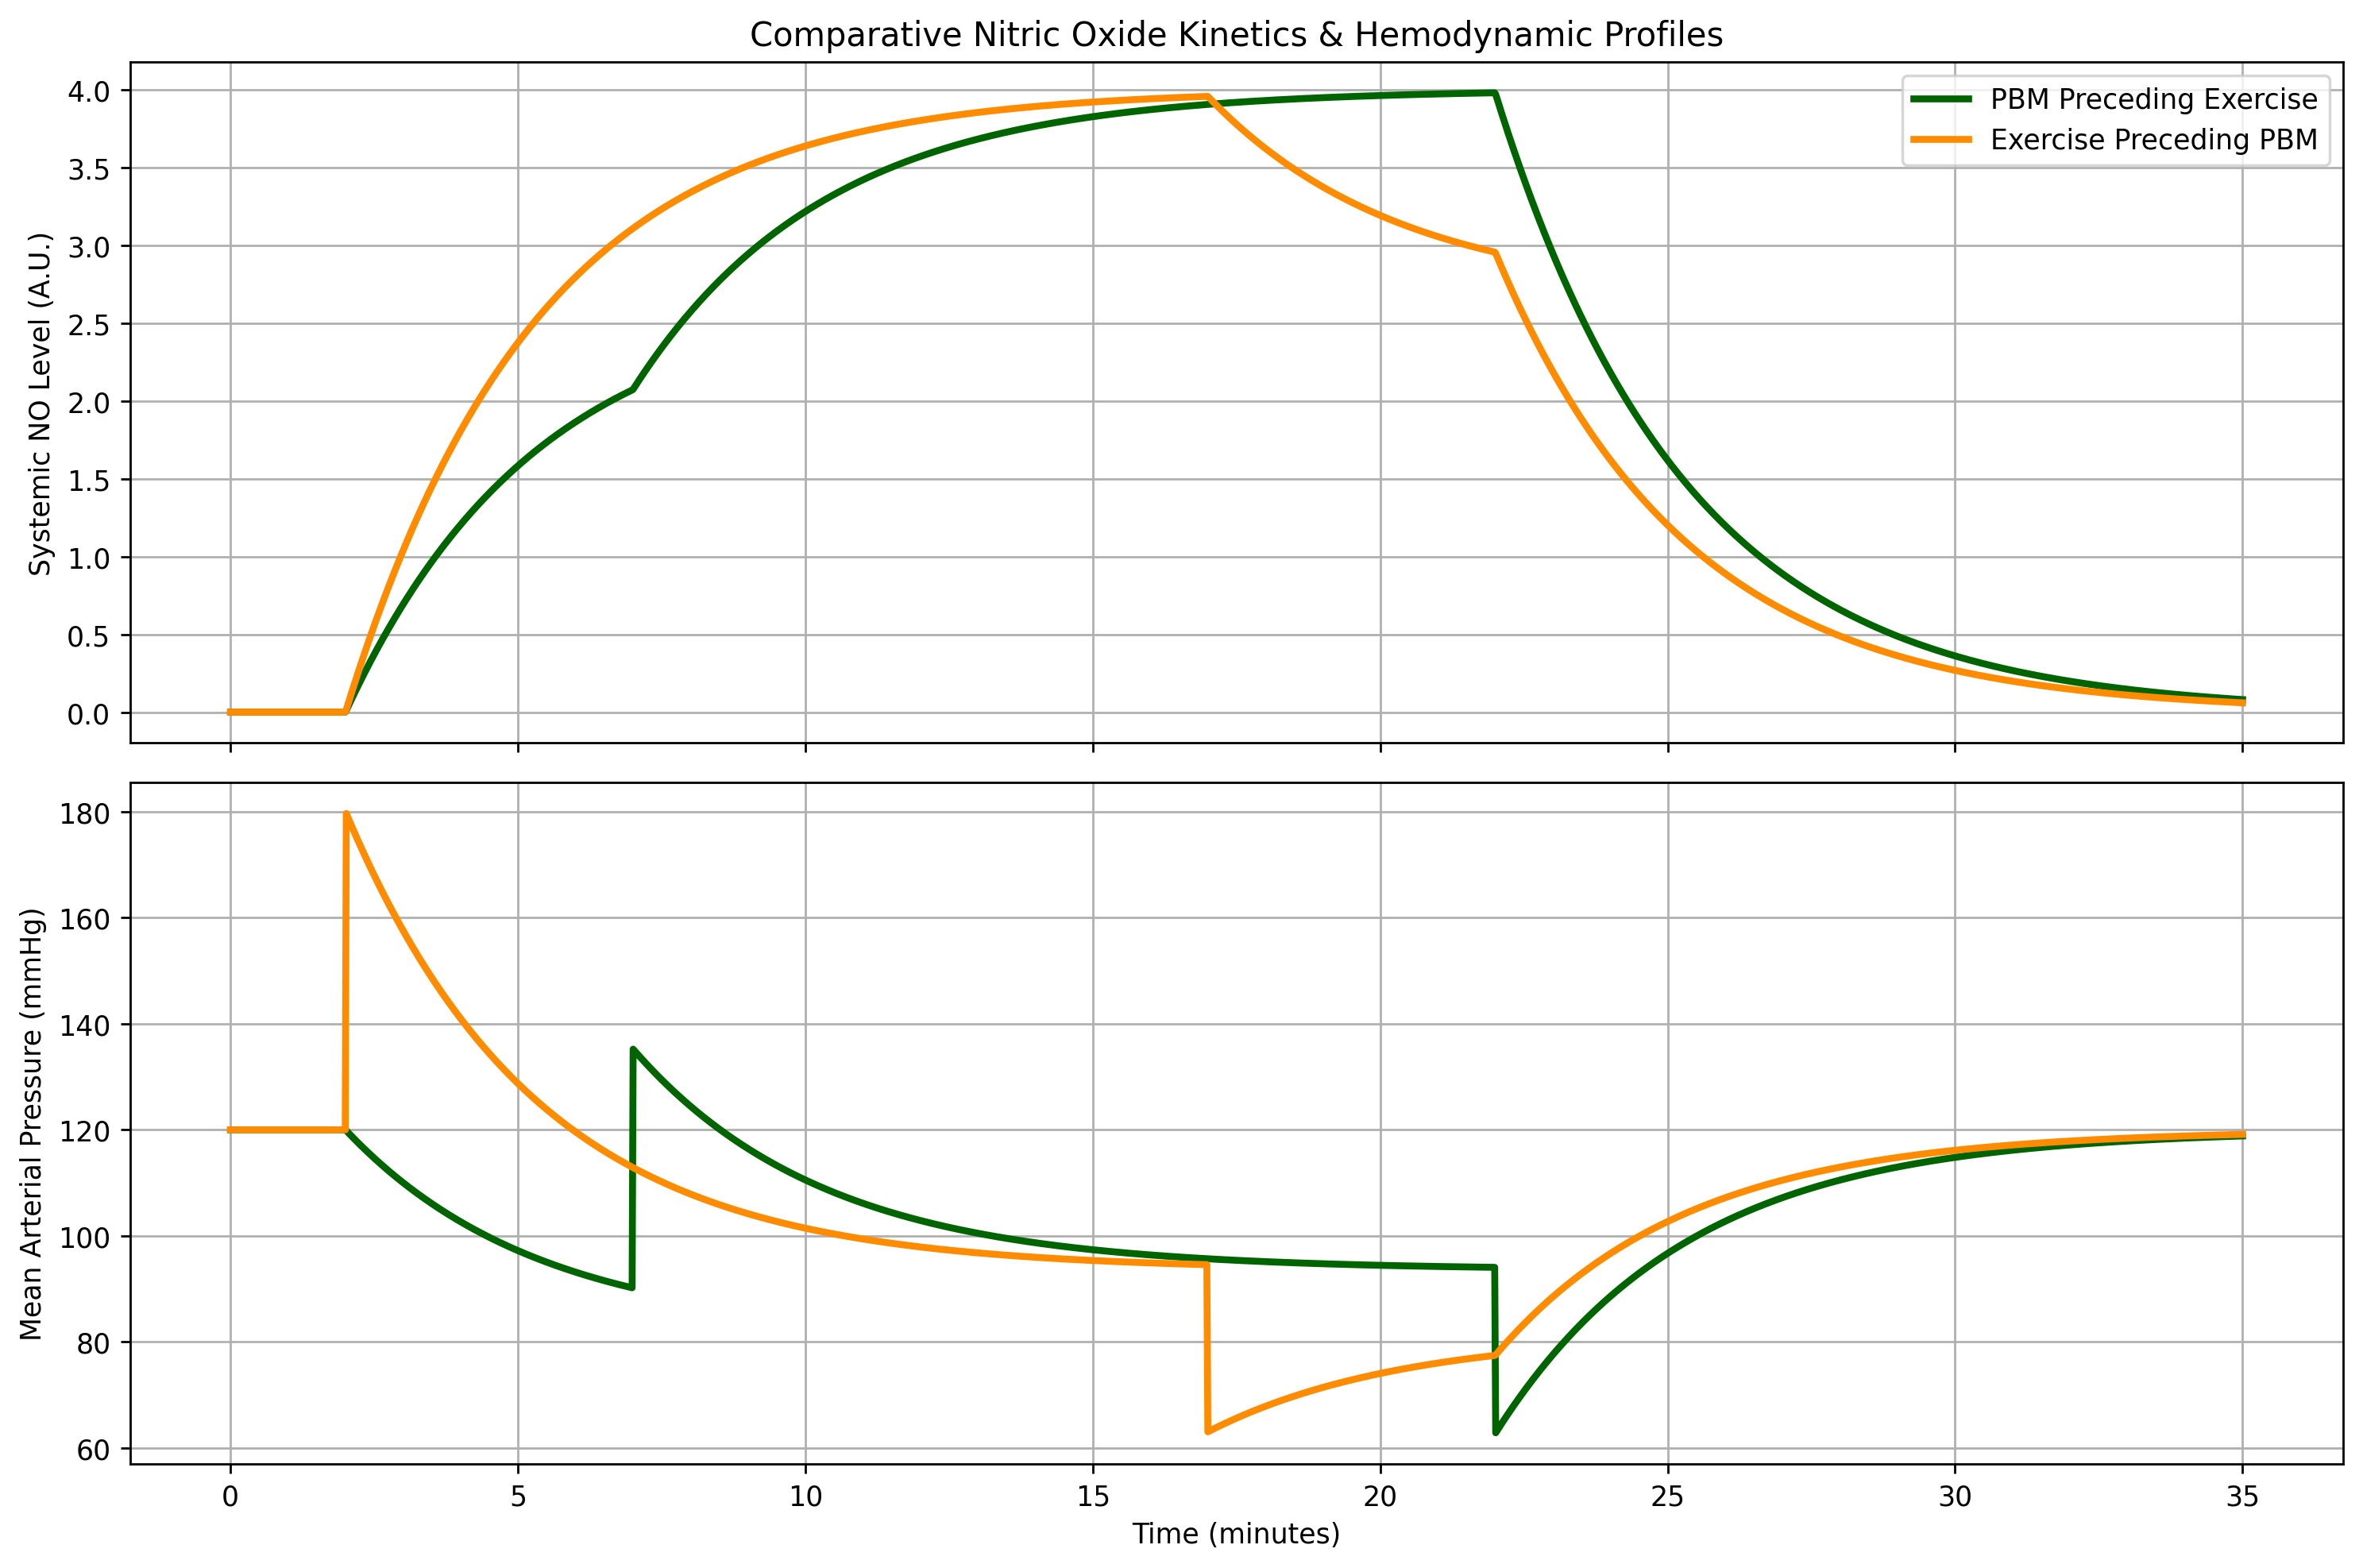

In [3]:
"""
Simulates the comparative hemodynamic effects of sequential therapy timing.
This formal module evaluates the exact physiological differences between applying
photobiomodulation prior to physical exercise versus the reverse sequence.
"""

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# System parameters and high-fidelity plotting configurations
plt.rcParams['figure.dpi'] = 250
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# =============================================================================
# CONTROL KNOBS (Adjustable Physiological & Simulation Parameters)
# =============================================================================
SIMULATION_END_TIME = 35.0       # Total duration (minutes) of the simulation
TIME_STEPS = 2000                # Resolution of the numerical simulation

PBM_DURATION = 5.0               # Duration (minutes) of light therapy
EXERCISE_DURATION = 15.0         # Duration (minutes) of aerobic activity

# Scenario A parameters (Optical PBM preceding Aerobic Exercise)
SCENARIO_A_PBM_START = 2.0
SCENARIO_A_EX_START = 7.0

# Scenario B parameters (Aerobic Exercise preceding Optical PBM)
SCENARIO_B_EX_START = 2.0
SCENARIO_B_PBM_START = 17.0

BASELINE_MAP = 120.0             # Initial Mean Arterial Pressure (mmHg)
BASELINE_TPR = 1.0               # Normalized Total Peripheral Resistance
BASELINE_CO = BASELINE_MAP / BASELINE_TPR # Baseline Cardiac Output

# Kinetic rate constants governing vascular dynamics
K_PHOTO = 0.8                    # Photochemical NO production rate
K_MECH = 1.2                     # Mechanical (shear stress) NO production rate
K_DECAY = 0.3                    # Biological NO decay rate
ALPHA = 0.12                     # Vasodilation sensitivity to NO
EXERCISE_CO_MULTIPLIER = 1.5     # Cardiac output increase during active exercise
# =============================================================================

def get_stimulus(t, pbm_start, ex_start):
    """
    Determines the active temporal states of the optical and physical therapies.
    """
    pbm_active = 1.0 if (pbm_start <= t <= pbm_start + PBM_DURATION) else 0.0
    ex_active = 1.0 if (ex_start <= t <= ex_start + EXERCISE_DURATION) else 0.0
    return pbm_active, ex_active

def physiological_derivatives(state, t, pbm_start, ex_start):
    """
    Calculates the continuous time derivatives for the physiological state variables.
    """
    no_concentration = state[0]
    pbm_active, ex_active = get_stimulus(t, pbm_start, ex_start)

    production = (K_PHOTO * pbm_active) + (K_MECH * ex_active)
    decay = K_DECAY * no_concentration

    d_no_dt = production - decay
    return [d_no_dt]

def run_comparative_simulation():
    """
    Executes the dual numerical integrations and renders the comparative plots.
    """
    time_array = np.linspace(0, SIMULATION_END_TIME, TIME_STEPS)
    initial_state = [0.0]

    # Mathematical Integration for Scenario A
    solution_a = odeint(
        physiological_derivatives,
        initial_state,
        time_array,
        args=(SCENARIO_A_PBM_START, SCENARIO_A_EX_START)
    )
    no_a = solution_a[:, 0]

    # Mathematical Integration for Scenario B
    solution_b = odeint(
        physiological_derivatives,
        initial_state,
        time_array,
        args=(SCENARIO_B_PBM_START, SCENARIO_B_EX_START)
    )
    no_b = solution_b[:, 0]

    # Evaluate dynamic physiological parameters using algebraic transformations
    def calculate_map(no_array, time_array, ex_start):
        map_array = np.zeros_like(time_array)
        for idx, t in enumerate(time_array):
            _, ex_active = get_stimulus(t, 0, ex_start)
            current_co = BASELINE_CO * (EXERCISE_CO_MULTIPLIER if ex_active else 1.0)
            current_tpr = BASELINE_TPR * (1.0 - ALPHA * no_array[idx])
            map_array[idx] = current_co * current_tpr
        return map_array

    map_a = calculate_map(no_a, time_array, SCENARIO_A_EX_START)
    map_b = calculate_map(no_b, time_array, SCENARIO_B_EX_START)

    # Constructing the comprehensive visual representation
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    ax1.plot(time_array, no_a, color='darkgreen', linewidth=2.5, label='PBM Preceding Exercise')
    ax1.plot(time_array, no_b, color='darkorange', linewidth=2.5, label='Exercise Preceding PBM')
    ax1.set_ylabel('Systemic NO Level (A.U.)')
    ax1.set_title('Comparative Nitric Oxide Kinetics & Hemodynamic Profiles')
    ax1.legend(loc='upper right')

    ax2.plot(time_array, map_a, color='darkgreen', linewidth=2.5)
    ax2.plot(time_array, map_b, color='darkorange', linewidth=2.5)
    ax2.set_xlabel('Time (minutes)')
    ax2.set_ylabel('Mean Arterial Pressure (mmHg)')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_comparative_simulation()